# Student Performance Prediction — Linear Regression, Ridge & Lasso Comparison

**Problem Statement:** Predict a continuous target (`Performance Index`) using Linear
Regression. Apply Ridge and Lasso regularization, compare coefficients, and evaluate all
three models using MAE, MSE, RMSE, and R² to determine which model generalizes best.

**Dataset:** [Student Performance (Multiple Linear Regression)](https://www.kaggle.com/datasets/nikhil7280/student-performance-multiple-linear-regression) — 10,000 student records.

**Deliverables:**
- Notebook with train/test split, Linear/Ridge/Lasso models
- Comparison table of MAE / MSE / RMSE / R² across the 3 models
- Conclusion on the best model and the effect of regularization


## 1. Load the Data

In [6]:
import pandas as pd

df = pd.read_csv("Student_Performance.csv")
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


## 2. Exploratory Data Analysis (EDA)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [8]:
df.isnull().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

In [9]:
df.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


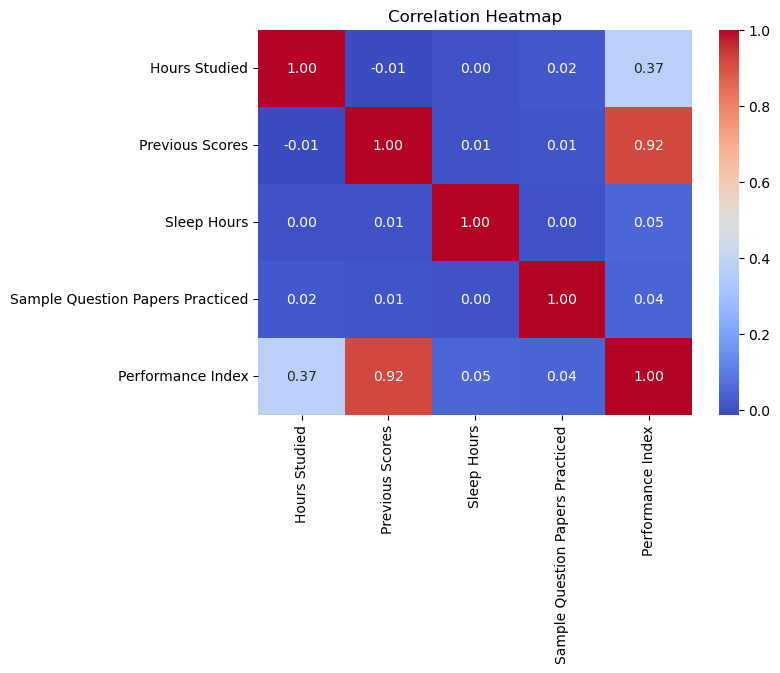

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## 3. Preprocessing — Encode Categorical Feature

In [11]:
df["Extracurricular Activities"] = df["Extracurricular Activities"].map({"Yes": 1, "No": 0})
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


## 4. Feature / Target Split

In [12]:
X = df.drop(columns=["Performance Index"])
y = df["Performance Index"]

X.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
0,7,99,1,9,1
1,4,82,0,4,2
2,8,51,1,7,2
3,5,52,1,5,2
4,7,75,0,8,5


## 5. Train/Test Split

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)

(8000, 5) (2000, 5)


## 6. Feature Scaling

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
X_train_scaled[:5]

array([[ 0.00645547, -1.18384439, -0.98930717,  0.26988848,  0.13404112],
       [-1.14974745, -1.24150571,  1.01080841,  0.26988848,  0.48356164],
       [-1.14974745,  0.66131759, -0.98930717,  0.26988848, -0.91452044],
       [-1.14974745, -1.35682833, -0.98930717, -0.31890558, -1.26404096],
       [ 1.16265838, -1.29916702, -0.98930717,  1.4474766 , -1.61356148]])

## 7. Model 1: Linear Regression

In [16]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

In [17]:
print(lr.intercept_)
print(lr.coef_)

55.31150000000001
[ 7.40134079 17.63727127  0.30429076  0.81003107  0.54884171]


## 8. Evaluate Linear Regression

In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("MAE:", mae_lr)
print("MSE:", mse_lr)
print("RMSE:", rmse_lr)
print("R2:", r2_lr)

MAE: 1.611121346312305
MSE: 4.082628398521859
RMSE: 2.0205515085050068
R2: 0.9889832909573145


## 9. Model 2: Ridge Regression

In [19]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

y_pred_ridge = ridge.predict(X_test_scaled)

In [20]:
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("MAE:", mae_ridge)
print("MSE:", mse_ridge)
print("RMSE:", rmse_ridge)
print("R2:", r2_ridge)

MAE: 1.6112232352490101
MSE: 4.083211446953204
RMSE: 2.0206957828810364
R2: 0.9889817176387807


## 10. Model 3: Lasso Regression

In [21]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)

y_pred_lasso = lasso.predict(X_test_scaled)

In [22]:
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print("MAE:", mae_lasso)
print("MSE:", mse_lasso)
print("RMSE:", rmse_lasso)
print("R2:", r2_lasso)

MAE: 1.6267286509933805
MSE: 4.175297230950129
RMSE: 2.043354406594737
R2: 0.988733230098345


## 11. Model Comparison Table

In [23]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge", "Lasso"],
    "MAE": [mae_lr, mae_ridge, mae_lasso],
    "MSE": [mse_lr, mse_ridge, mse_lasso],
    "RMSE": [rmse_lr, rmse_ridge, rmse_lasso],
    "R2": [r2_lr, r2_ridge, r2_lasso]
})

results

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,1.611121,4.082628,2.020552,0.988983
1,Ridge,1.611223,4.083211,2.020696,0.988982
2,Lasso,1.626729,4.175297,2.043354,0.988733


## 12. Coefficient Comparison

In [24]:
coef_table = pd.DataFrame({
    "Feature": X.columns,
    "Linear": lr.coef_,
    "Ridge": ridge.coef_,
    "Lasso": lasso.coef_
})

coef_table

,Feature,Linear,Ridge,Lasso
0,Hours Studied,7.401341,7.400393,7.302709
1,Previous Scores,17.637271,17.635057,17.537491
2,Extracurricular Activities,0.304291,0.304260,0.202746
3,Sleep Hours,0.810031,0.809936,0.708700
4,Sample Question Papers Practiced,0.548842,0.548810,0.451249


## Conclusion

Linear Regression performed best overall, with the lowest MAE (1.611) and RMSE (2.021), and the highest R² (0.9890), though Ridge was virtually tied (MAE 1.611, RMSE 2.021, R² 0.9890). Ridge's coefficients were almost identical to Linear Regression's, suggesting the features aren't strongly correlated with each other and the relationships are close to linear, so there was little overfitting for regularization to fix. Lasso shrank coefficients the most (e.g., Extracurricular Activities dropped from 0.304 to 0.203) but didn't zero out any feature completely, showing that all five predictors contribute some real signal — and here regularization had only a small effect, slightly hurting accuracy rather than helping, because the data was already well-behaved and didn't need it.